In [1]:
import tensorflow as tf

# tf.__version__

In [2]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
datas= pd.read_excel("D:\TASK\CP rates\Cogencis data\Tbill364_data.xlsx", sheet_name='Sheet2',
                                                        parse_dates=['Date'], index_col='Date')
print(datas.shape)
datas.head(5)

(999, 1)


,Yield
Date,
1992-04-28,11.4206
1992-05-13,11.4206
1992-05-27,11.4206
1992-06-09,11.4206
1992-06-24,11.4206


In [5]:
import calendar

#comment to check the no of days 
calendar._monthlen(2018,5)

31

In [6]:
results={}
for i in range(1,13):
    results[f"datas_{i}"]=datas[(datas.index>=pd.to_datetime("2006-01-01")) & (datas.index<=pd.to_datetime(f"2018-{i}-{calendar._monthlen(2018,i)}"))]

In [7]:
for i in range(1,13):
    results[f"datas_{i+12}"]=datas[(datas.index>=pd.to_datetime("2006-01-04")) & (datas.index<=pd.to_datetime(f"2019-{i}-{calendar._monthlen(2019,i)}"))]

In [8]:
results['datas_24']

,Yield
Date,
2006-01-04,6.1288
2006-01-18,6.2985
2006-02-01,6.7421
2006-02-15,6.8106
2006-03-01,6.7992
...,...
2019-11-27,5.1389
2019-12-04,5.0990
2019-12-11,5.2476


### Forecast data

In [9]:
# keep Dec, Jan and feb data in seperate dataframe
# dfs= datas.tail(4)
# dfs.head()

unseen={}
for i in range(1,25):
    unseen[f"{i}"]=results[f"datas_{i}"][-4:]

In [10]:
unseen['24']

,Yield
Date,
2019-12-04,5.0990
2019-12-11,5.2476
2019-12-18,5.2665
2019-12-24,5.3000


### Training data

In [11]:
# Taking the data from Jan-2010 to till Nov-2023 for training
# data= datas.iloc[0:-4,:]
# data.tail()

d={}
for i in range(1,25):
    d[f"{i}"]=results[f"datas_{i}"][:-4]

In [12]:
d['24']

,Yield
Date,
2006-01-04,6.1288
2006-01-18,6.2985
2006-02-01,6.7421
2006-02-15,6.8106
2006-03-01,6.7992
...,...
2019-10-30,5.2998
2019-11-06,5.2397
2019-11-13,5.2298


### Train-Test split

In [13]:
# train_size = int(len(data)*0.80)
# test_size = len(data)-train_size 
# print(train_size, test_size)
#train_data, test_data= df.iloc[0:train_size,:], df.iloc[train_size:len(df),:]
# print(train_data.shape, test_data.shape)


train={}
val={}
for i in range(1,25):
    train[f"{i}"]=d[f"{i}"][:int(len(d[f"{i}"])*0.8)]
    val[f"{i}"]=d[f"{i}"][int(len(d[f"{i}"])*0.8):]

In [14]:
for i in range(1,25):
    print(train[f"{i}"].shape,val[f"{i}"].shape)

(257, 1) (65, 1)
(260, 1) (66, 1)
(264, 1) (66, 1)
(267, 1) (67, 1)
(271, 1) (68, 1)
(274, 1) (69, 1)
(277, 1) (70, 1)
(281, 1) (71, 1)
(284, 1) (72, 1)
(288, 1) (73, 1)
(292, 1) (73, 1)
(295, 1) (74, 1)
(299, 1) (75, 1)
(302, 1) (76, 1)
(305, 1) (77, 1)
(309, 1) (78, 1)
(312, 1) (79, 1)
(316, 1) (79, 1)
(320, 1) (80, 1)
(323, 1) (81, 1)
(326, 1) (82, 1)
(330, 1) (83, 1)
(333, 1) (84, 1)
(336, 1) (85, 1)


In [15]:
train['1']

,Yield
Date,
2006-01-04,6.1288
2006-01-18,6.2985
2006-02-01,6.7421
2006-02-15,6.8106
2006-03-01,6.7992
...,...
2015-08-19,7.5360
2015-09-02,7.5012
2015-09-16,7.5012


#### user defined function to create a x and y using window size, example like below
           x            y 
 * [[[1],[2],[3],[4],[5]]]    [6]
 * [[[2],[3],[4],[5],[6]]]    [7]
 * [[[3],[4],[5],[6],[7]]]    [8]

In [16]:
# convert an array of values into a dataset matrix

def data_to_x_y(X, y, num_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - num_steps):
        Xs.append(X.iloc[i:(i + num_steps)].values)       
        ys.append(y.iloc[i + num_steps])
    return np.array(Xs), np.array(ys)


In [17]:
trainX, trainY={}, {}
valX, valY ={}, {}

num_steps= 5


for i in range(1,25):
    # reshape into X=t,t+1,t+2,t+3 and Y=t+4
    trainX[f"{i}"], trainY[f"{i}"] = data_to_x_y(train[f"{i}"], train[f"{i}"]['Yield'], num_steps)
    valX[f"{i}"], valY[f"{i}"] = data_to_x_y(val[f"{i}"], val[f"{i}"]['Yield'], num_steps)
    # print(train_x.shape, train_y.shape)

In [18]:
for i in range(1,25):
    print(trainX[f"{i}"].shape)
    print(trainY[f"{i}"].shape)
    print(valX[f"{i}"].shape)
    print(valY[f"{i}"].shape)

(252, 5, 1)
(252,)
(60, 5, 1)
(60,)
(255, 5, 1)
(255,)
(61, 5, 1)
(61,)
(259, 5, 1)
(259,)
(61, 5, 1)
(61,)
(262, 5, 1)
(262,)
(62, 5, 1)
(62,)
(266, 5, 1)
(266,)
(63, 5, 1)
(63,)
(269, 5, 1)
(269,)
(64, 5, 1)
(64,)
(272, 5, 1)
(272,)
(65, 5, 1)
(65,)
(276, 5, 1)
(276,)
(66, 5, 1)
(66,)
(279, 5, 1)
(279,)
(67, 5, 1)
(67,)
(283, 5, 1)
(283,)
(68, 5, 1)
(68,)
(287, 5, 1)
(287,)
(68, 5, 1)
(68,)
(290, 5, 1)
(290,)
(69, 5, 1)
(69,)
(294, 5, 1)
(294,)
(70, 5, 1)
(70,)
(297, 5, 1)
(297,)
(71, 5, 1)
(71,)
(300, 5, 1)
(300,)
(72, 5, 1)
(72,)
(304, 5, 1)
(304,)
(73, 5, 1)
(73,)
(307, 5, 1)
(307,)
(74, 5, 1)
(74,)
(311, 5, 1)
(311,)
(74, 5, 1)
(74,)
(315, 5, 1)
(315,)
(75, 5, 1)
(75,)
(318, 5, 1)
(318,)
(76, 5, 1)
(76,)
(321, 5, 1)
(321,)
(77, 5, 1)
(77,)
(325, 5, 1)
(325,)
(78, 5, 1)
(78,)
(328, 5, 1)
(328,)
(79, 5, 1)
(79,)
(331, 5, 1)
(331,)
(80, 5, 1)
(80,)


In [18]:
# reshape input to be [samples, time steps, features] which is required for LSTM

# train_X = train_x.reshape(train_x.shape[0],train_x.shape[1], 1)
# test_X = test_x.reshape(test_x.shape[0],test_x.shape[1], 1)
# print(train_X.shape, train_y.shape)

### Model Training

In [19]:
import tensorflow as tf
from tensorflow import keras

lstm_model={}

for i in range(1,25):
    lstm_model[f"{i}"] = keras.Sequential()
    lstm_model[f"{i}"].add(keras.layers.LSTM(64, input_shape=(trainX[f"{i}"].shape[1], trainX[f"{i}"].shape[2]),return_sequences=True)) # input_shape=(n_input,n_features)
    lstm_model[f"{i}"].add(keras.layers.LSTM(16,activation='LeakyReLU'))
    lstm_model[f"{i}"].add(keras.layers.Dense(1, activation='linear'))
    lstm_model[f"{i}"].compile(loss='mean_squared_error', optimizer=keras.optimizers.Adam(0.001))

In [20]:
# Setting callbacks for saving the best model which have low val_losses 

# Model train
history={}
for i in range(1,25):
    history[f"{i}"] = lstm_model[f"{i}"].fit(trainX[f"{i}"], trainY[f"{i}"], 
                                        epochs=100, batch_size=16, 
                                        validation_data= (valX[f"{i}"],valY[f"{i}"]), 
                                        shuffle=False,
                                        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5),
                                        tf.keras.callbacks.ModelCheckpoint(f"model{'i'}.h5", monitor='val_loss', save_best_only=True)])

Epoch 1/100

16/16 [==============================] - 5s 65ms/step - loss: 51.2237 - val_loss: 28.6316
Epoch 2/100
10/16 [=================>............] - ETA: 0s - loss: 24.5586

c:\Users\manirathinams\AppData\Local\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


16/16 [==============================] - 0s 11ms/step - loss: 18.9597 - val_loss: 1.2771
Epoch 3/100
16/16 [==============================] - 0s 11ms/step - loss: 2.9703 - val_loss: 0.0392
Epoch 4/100
16/16 [==============================] - 0s 8ms/step - loss: 0.7009 - val_loss: 1.1886
Epoch 5/100
16/16 [==============================] - 0s 8ms/step - loss: 0.9295 - val_loss: 0.3095
Epoch 6/100
16/16 [==============================] - 0s 8ms/step - loss: 0.5413 - val_loss: 0.5086
Epoch 7/100
16/16 [==============================] - 0s 8ms/step - loss: 0.5365 - val_loss: 0.3908
Epoch 8/100
16/16 [==============================] - 0s 9ms/step - loss: 0.4593 - val_loss: 0.3022
Epoch 1/100
16/16 [==============================] - 5s 67ms/step - loss: 40.3453 - val_loss: 15.1358
Epoch 2/100
16/16 [==============================] - 0s 9ms/step - loss: 6.1475 - val_loss: 6.9336
Epoch 3/100
16/16 [==============================] - 0s 10ms/step - loss: 2.8899 - val_loss: 0.0362
Epoch 4/100
16/

In [32]:
for i in range(1,25):
    print(history[f"{i}"])

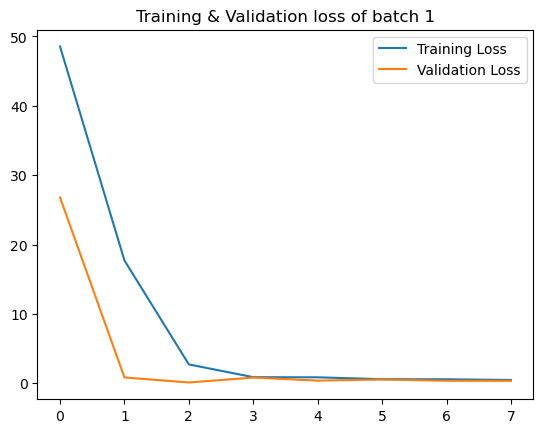

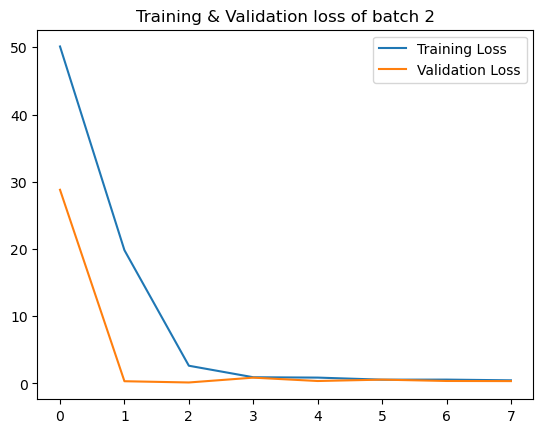

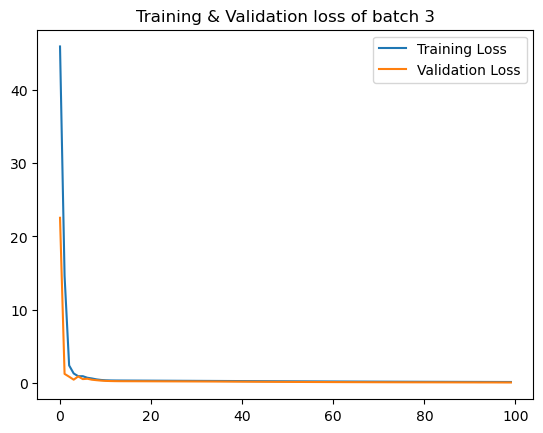

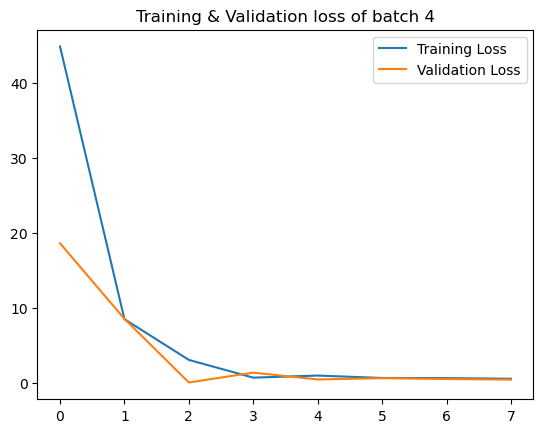

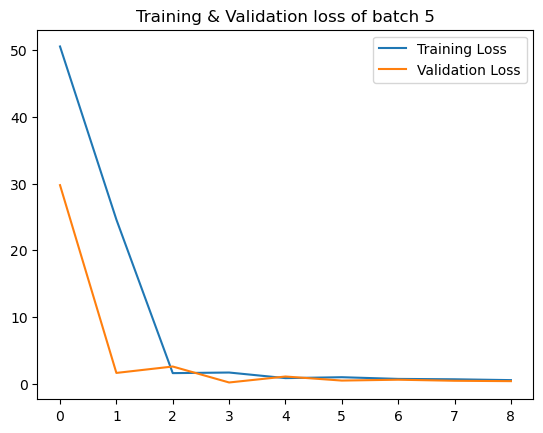

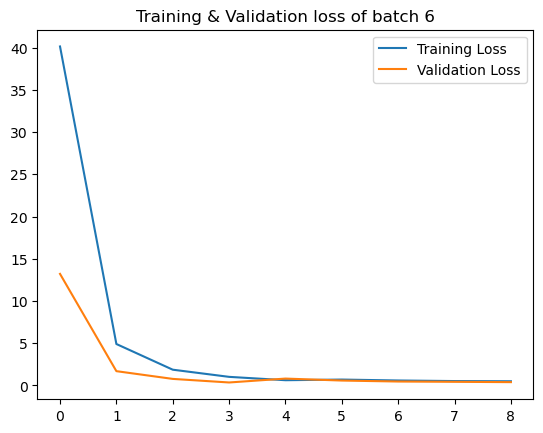

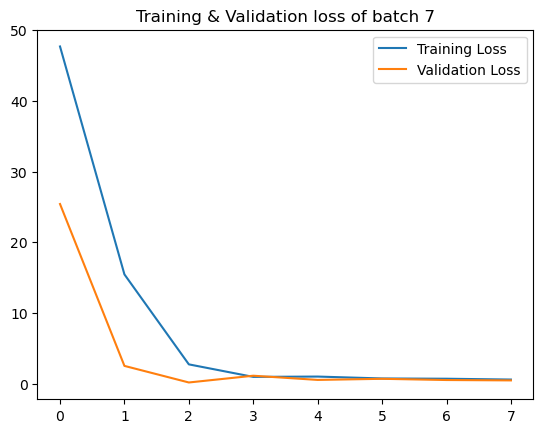

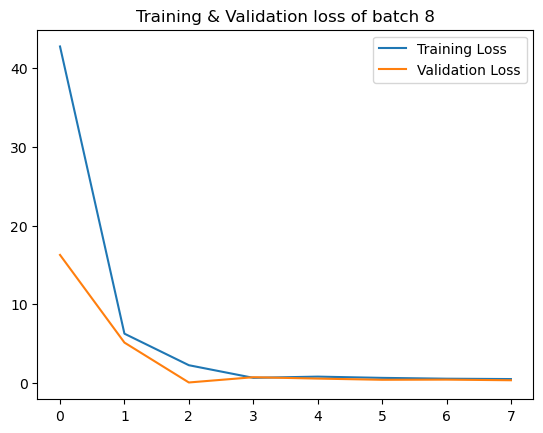

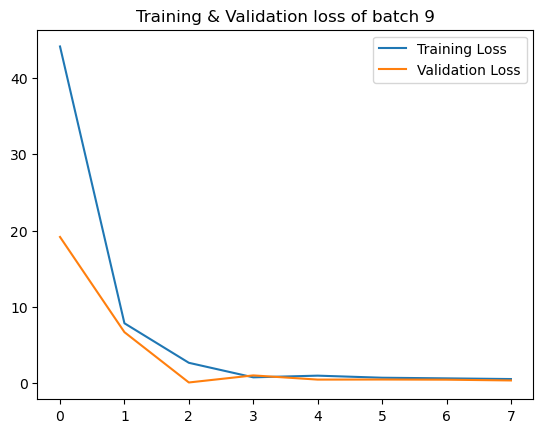

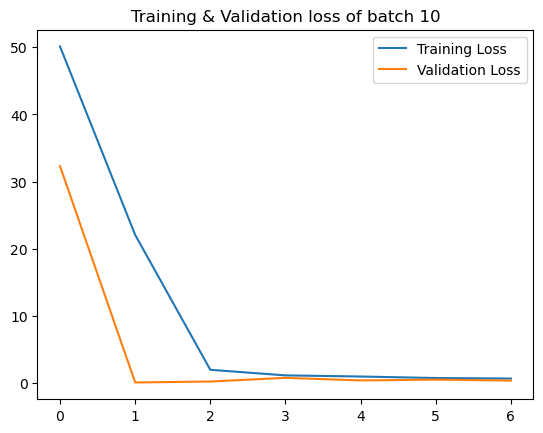

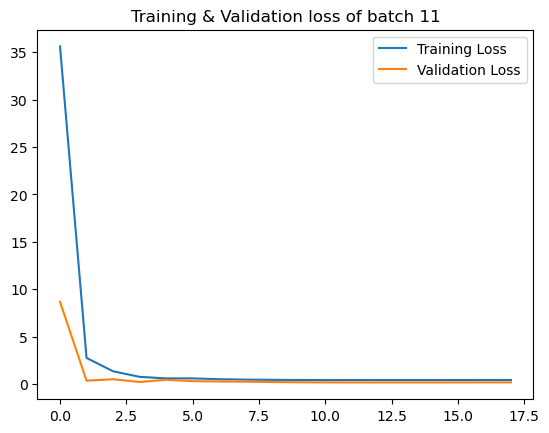

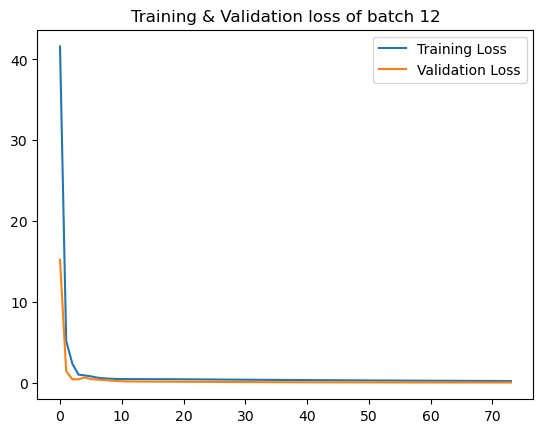

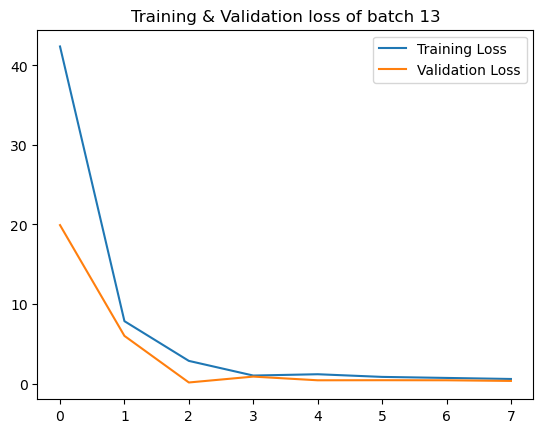

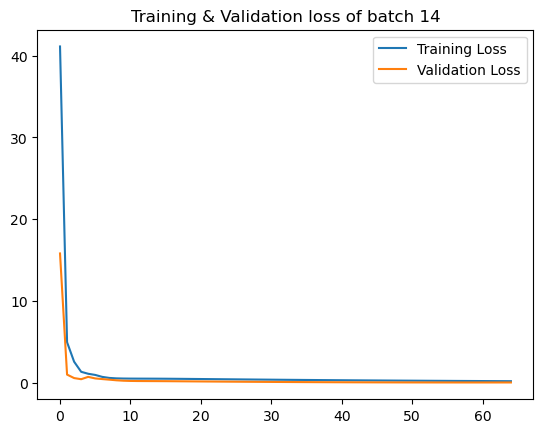

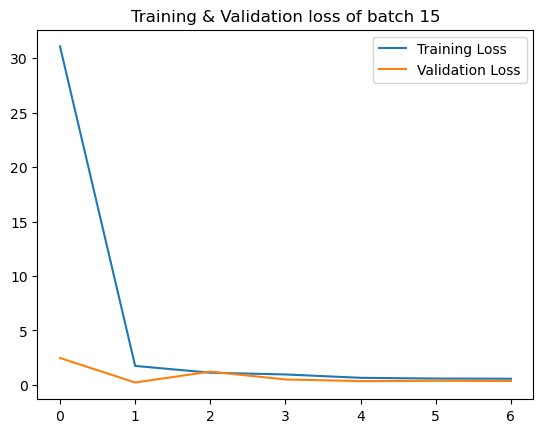

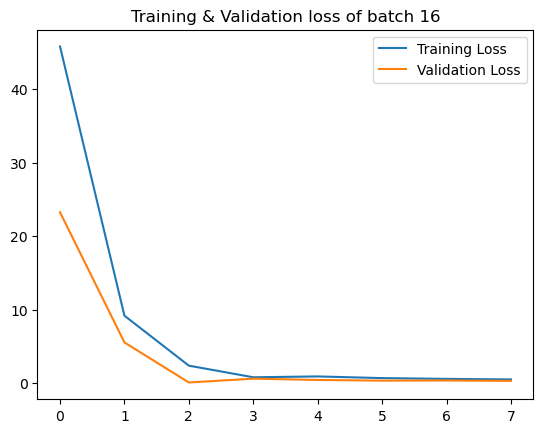

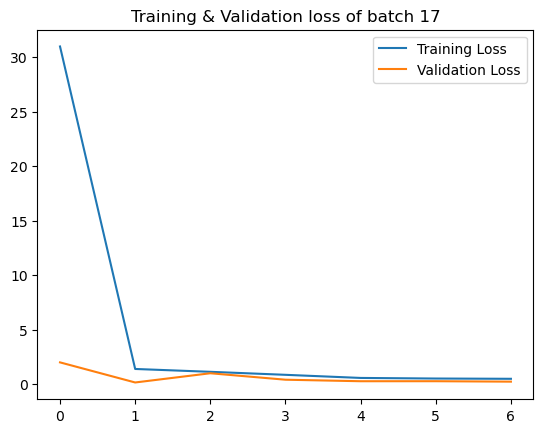

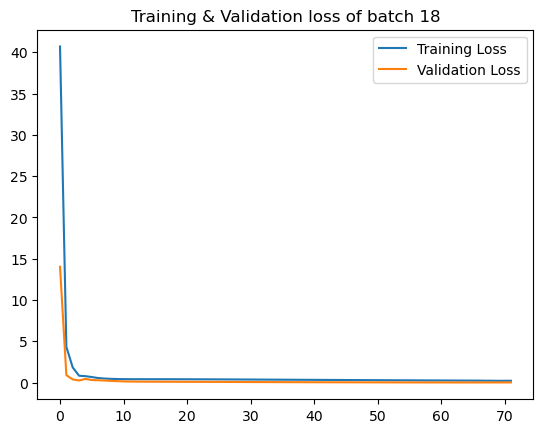

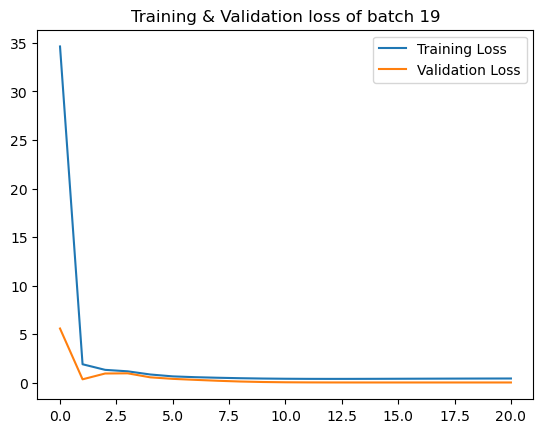

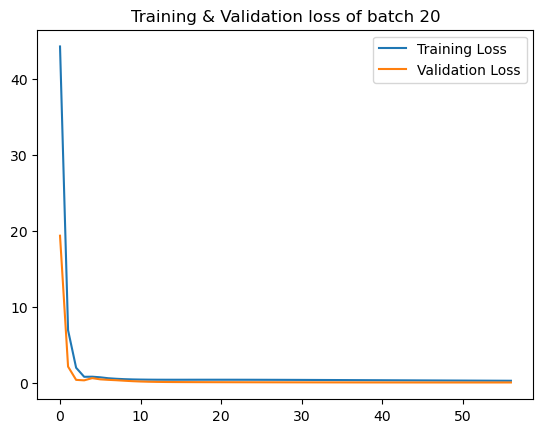

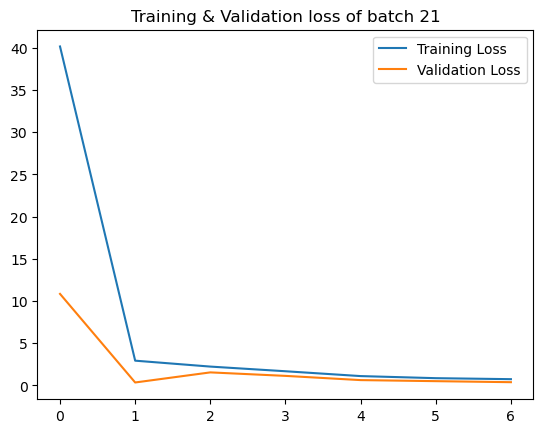

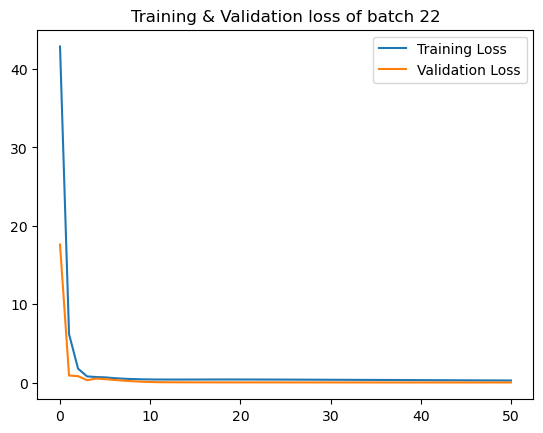

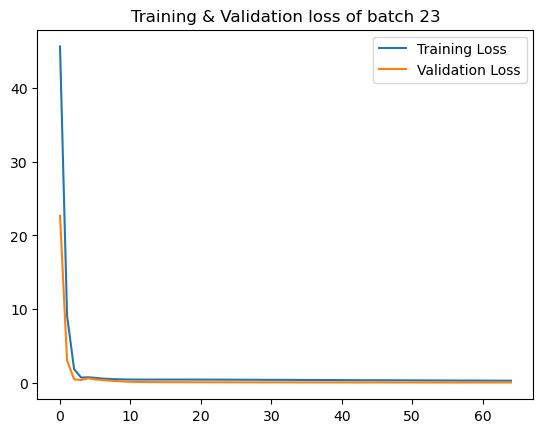

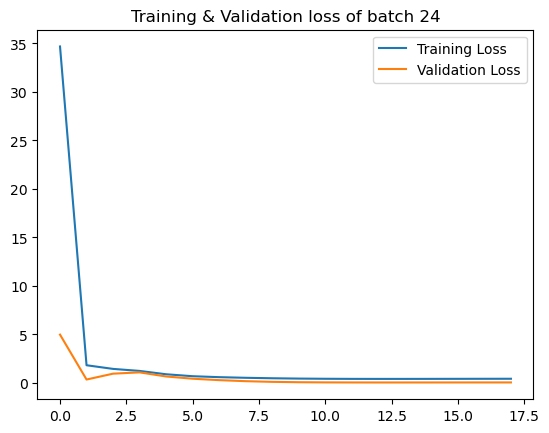

In [33]:
# Plotting the training and validation losses
import matplotlib.pyplot as plt

for i in range(1,25):
    plt.title(f"Training & Validation loss of batch {i}")
    plt.plot(history[f"{i}"].history['loss'], label='Training Loss')
    plt.plot(history[f"{i}"].history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.show();

###  Model_validation

2/2 [==============================] - 1s 3ms/step


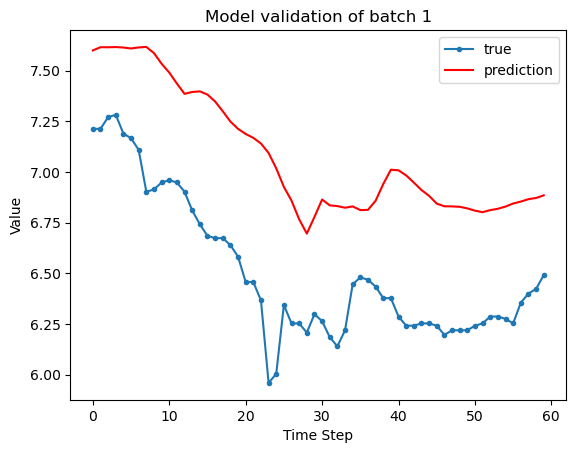

2/2 [==============================] - 0s 2ms/step


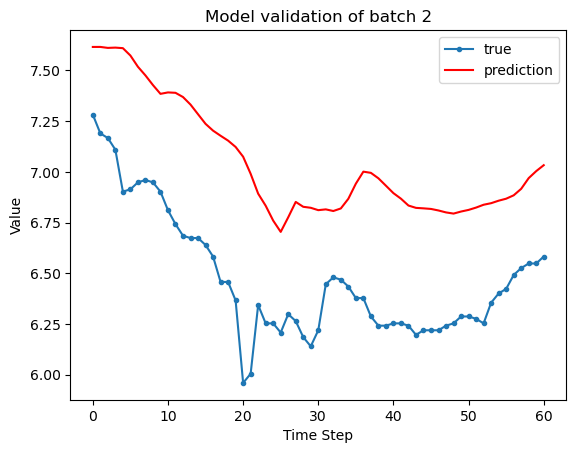

2/2 [==============================] - 0s 3ms/step


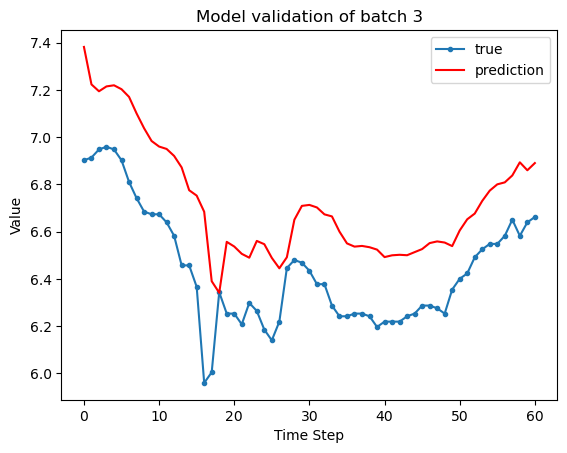

2/2 [==============================] - 0s 4ms/step


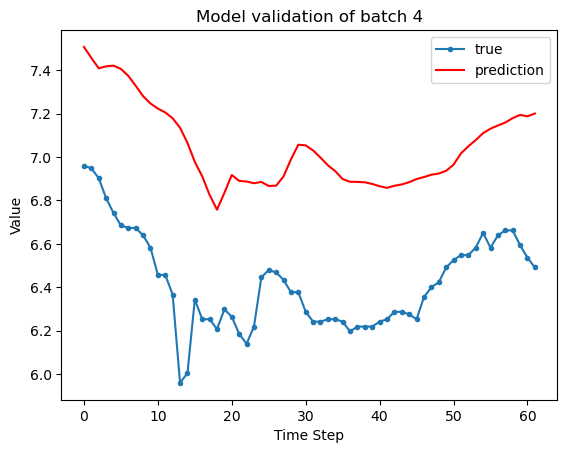

2/2 [==============================] - 0s 4ms/step


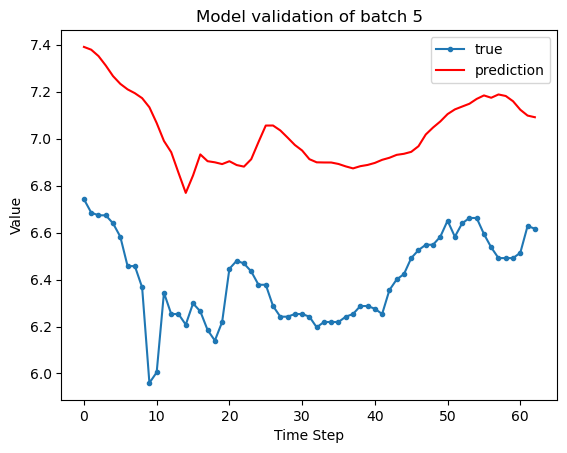

2/2 [==============================] - 0s 3ms/step


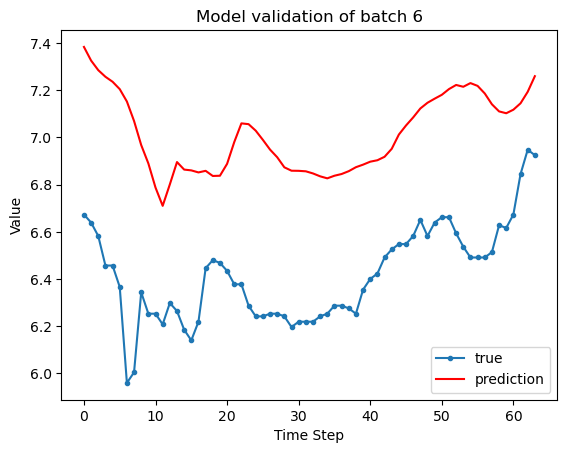

3/3 [==============================] - 0s 2ms/step


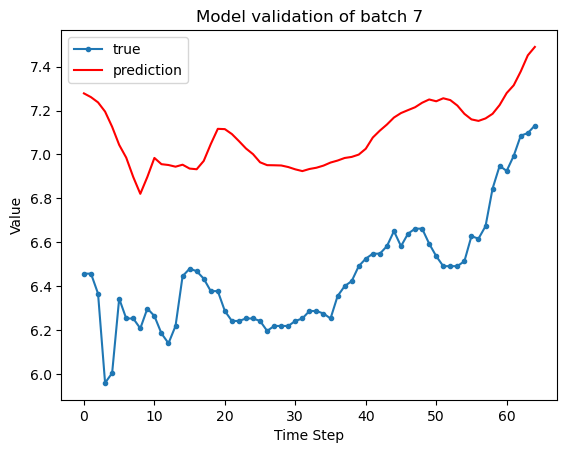

3/3 [==============================] - 0s 2ms/step


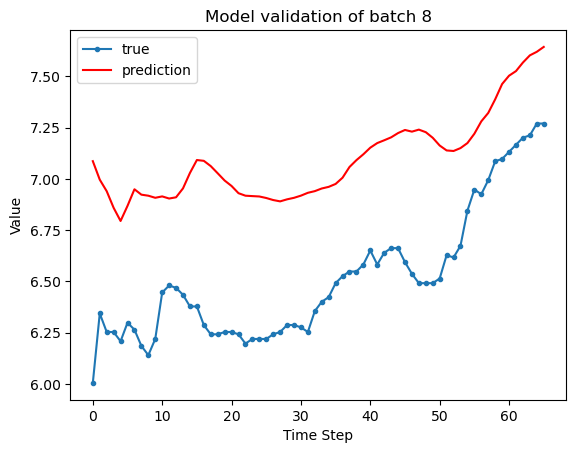

3/3 [==============================] - 0s 3ms/step


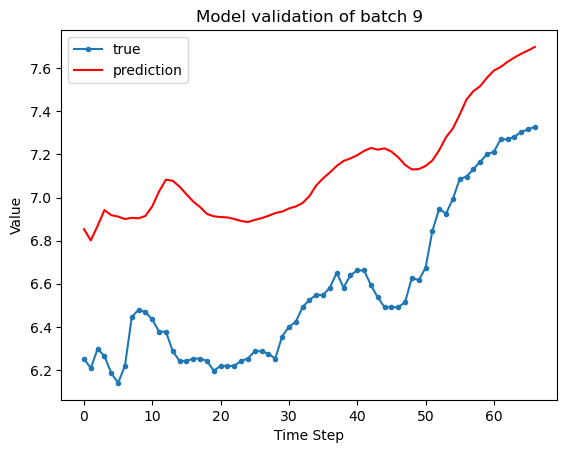

3/3 [==============================] - 0s 3ms/step


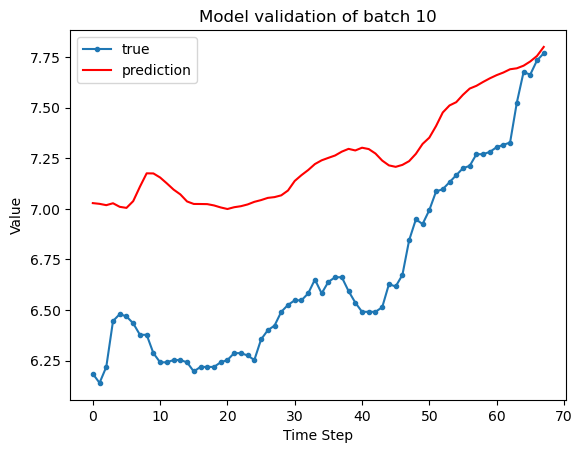

3/3 [==============================] - 0s 2ms/step


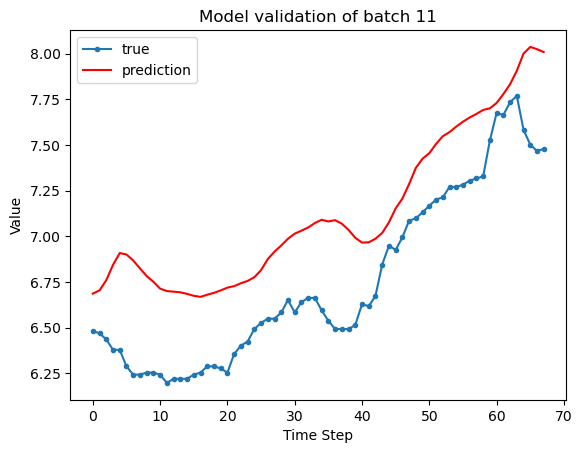

3/3 [==============================] - 0s 3ms/step


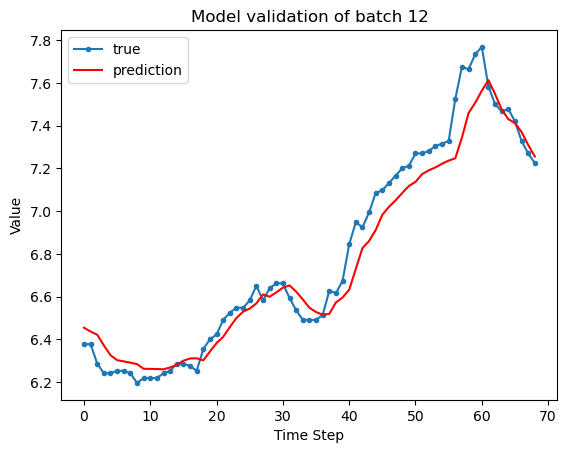

3/3 [==============================] - 0s 2ms/step


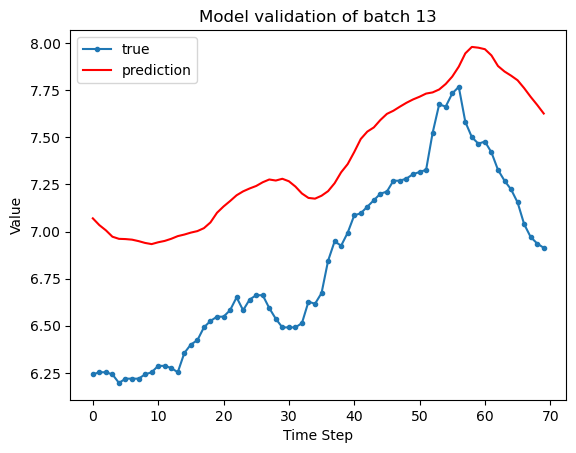

3/3 [==============================] - 0s 3ms/step


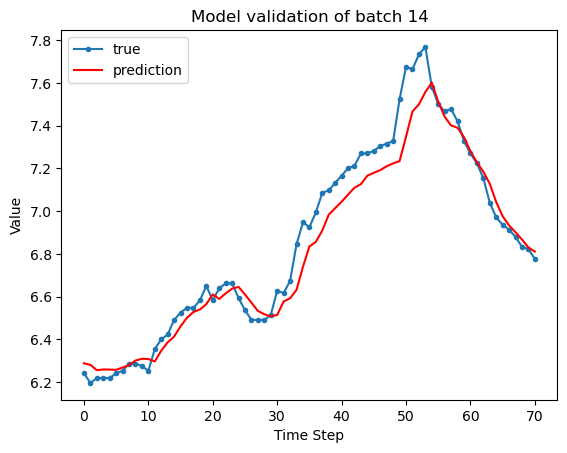

3/3 [==============================] - 0s 2ms/step


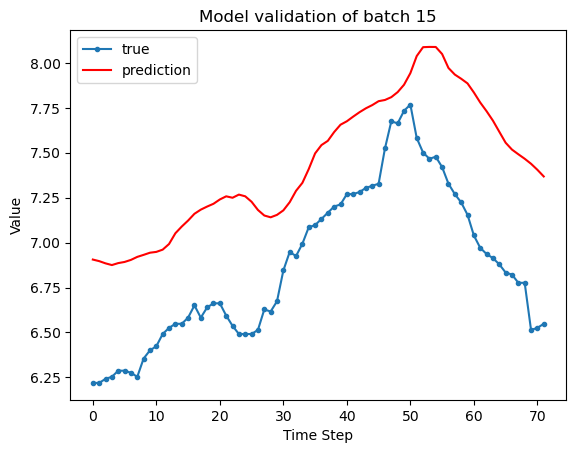

3/3 [==============================] - 0s 3ms/step


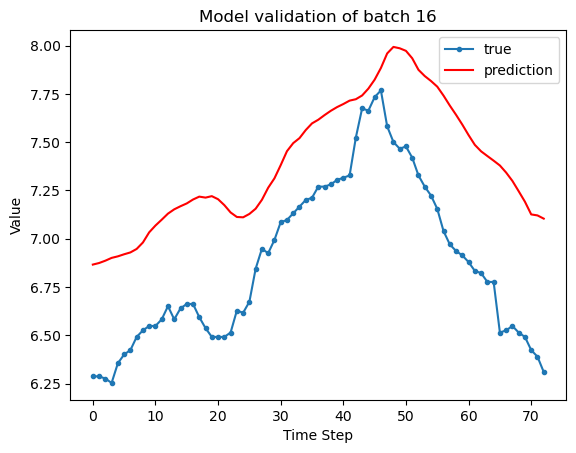

3/3 [==============================] - 0s 3ms/step


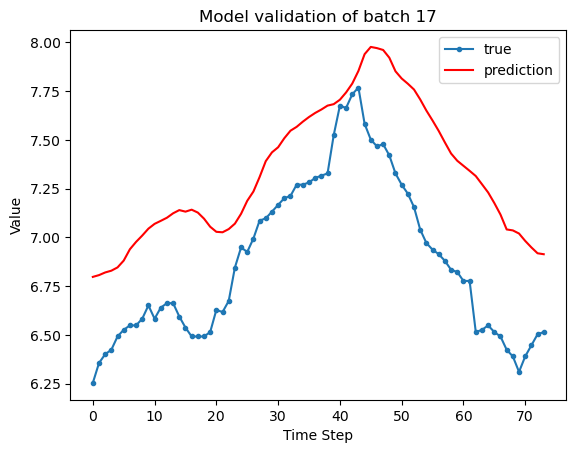

3/3 [==============================] - 0s 2ms/step


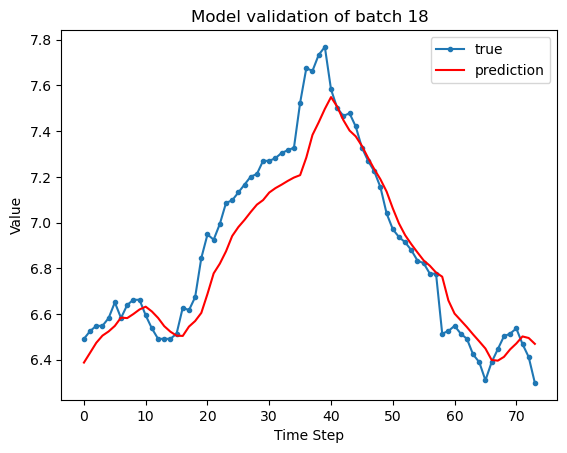

3/3 [==============================] - 0s 2ms/step


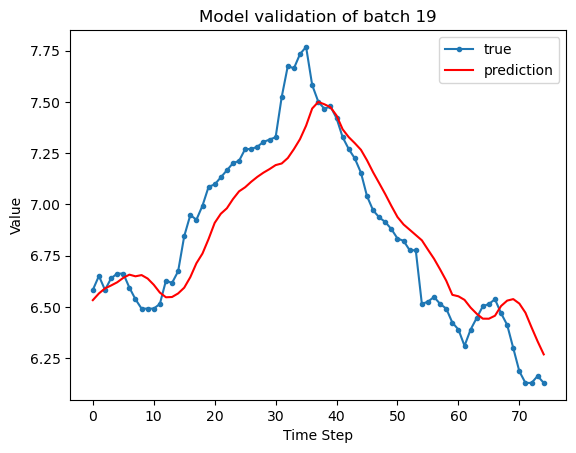

3/3 [==============================] - 0s 2ms/step


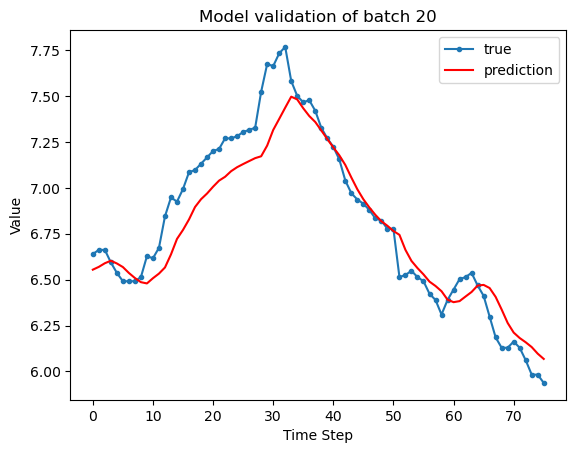

3/3 [==============================] - 0s 3ms/step


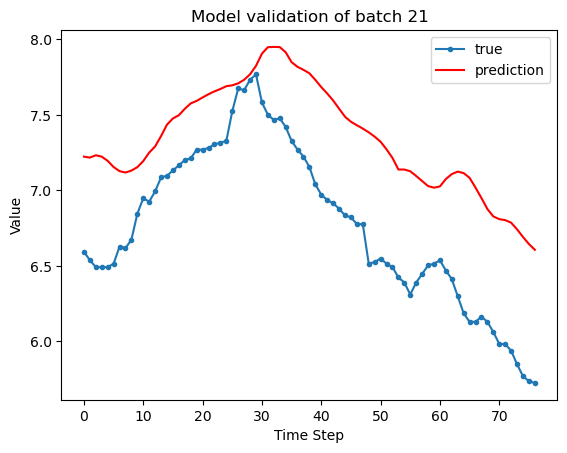

3/3 [==============================] - 0s 2ms/step


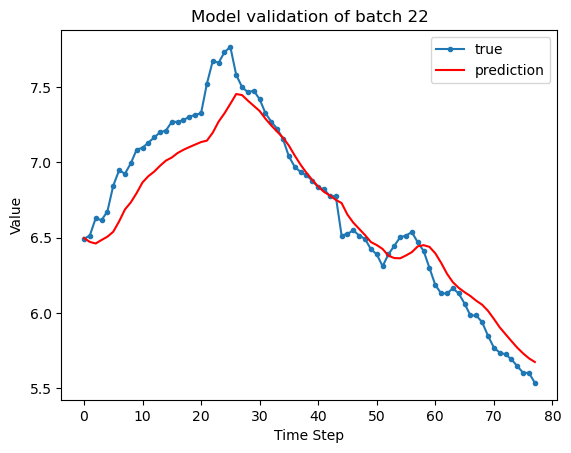

3/3 [==============================] - 0s 3ms/step


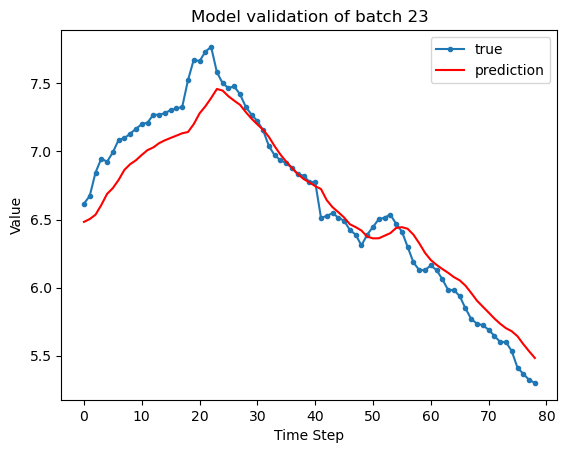

3/3 [==============================] - 0s 2ms/step


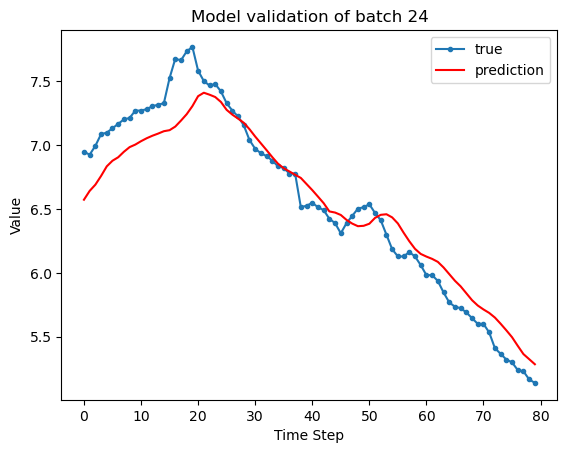

In [35]:
y_pred={}
for i in range(1,25):
    y_pred[f"{i}"] = lstm_model[f"{i}"].predict(valX[f"{i}"])
    plt.title(f"Model validation of batch {i}")
    plt.plot(valY[f"{i}"], marker='.', label="true")
    plt.plot(y_pred[f"{i}"], 'r', label="prediction")
    plt.ylabel('Value')
    plt.xlabel('Time Step')
    plt.legend()
    plt.show();

### Training RMSE Score

In [38]:
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse_y={}

for i in range(1,25):
    rmse_y[f"{i}"]=sqrt(mean_squared_error(valY[f"{i}"],y_pred[f"{i}"]))
    print("Mean value of Cut off Yield is : {},Root Mean Squared Error is: {}".format(np.mean(valY[f"{i}"]),rmse_y[f"{i}"]))

Mean value of Cut off Yield is : 6.507656666666667,Root Mean Squared Error is: 0.595843483667557
Mean value of Cut off Yield is : 6.474900000000002,Root Mean Squared Error is: 0.5855326761544293
Mean value of Cut off Yield is : 6.438650819672132,Root Mean Squared Error is: 0.30088599510857017
Mean value of Cut off Yield is : 6.423840322580644,Root Mean Squared Error is: 0.6371049153449663
Mean value of Cut off Yield is : 6.4031634920634914,Root Mean Squared Error is: 0.641868184528005
Mean value of Cut off Yield is : 6.417034375,Root Mean Squared Error is: 0.6191412550793783
Mean value of Cut off Yield is : 6.447747692307693,Root Mean Squared Error is: 0.6636120004604372
Mean value of Cut off Yield is : 6.514883333333333,Root Mean Squared Error is: 0.6002512072176812
Mean value of Cut off Yield is : 6.576277611940299,Root Mean Squared Error is: 0.5705739151550486
Mean value of Cut off Yield is : 6.675755882352941,Root Mean Squared Error is: 0.6245118491316584
Mean value of Cut off Yiel

### Take entire data as training for future forecasting to validate with business in future¶

In [40]:
dX={}
dY={}

num_steps=5
for i in range(1,25):
    dX[f"{i}"], dY[f"{i}"] = data_to_x_y(d[f"{i}"], d[f"{i}"]['Yield'], num_steps)

In [43]:
for i in range(1,25):
    print(dX[f"{i}"].shape)

(317, 5, 1)
(321, 5, 1)
(325, 5, 1)
(329, 5, 1)
(334, 5, 1)
(338, 5, 1)
(342, 5, 1)
(347, 5, 1)
(351, 5, 1)
(356, 5, 1)
(360, 5, 1)
(364, 5, 1)
(369, 5, 1)
(373, 5, 1)
(377, 5, 1)
(382, 5, 1)
(386, 5, 1)
(390, 5, 1)
(395, 5, 1)
(399, 5, 1)
(403, 5, 1)
(408, 5, 1)
(412, 5, 1)
(416, 5, 1)


In [45]:
history_f={}
for i in range(1,25):
    history_f[f"{i}"] = lstm_model[f"{i}"].fit(
        dX[f"{i}"], dY[f"{i}"],
        epochs=50,
        batch_size=16,
        validation_split=0.1,
        shuffle=False,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,mode='min',verbose=1),tf.keras.callbacks.ModelCheckpoint(f"lstm_model_fl{i}.h5", monitor='val_loss', save_best_only=True)]
    )

Epoch 1/50
18/18 [==============================] - 0s 9ms/step - loss: 0.4200 - val_loss: 0.1968
Epoch 2/50
18/18 [==============================] - 0s 6ms/step - loss: 0.4180 - val_loss: 0.1949
Epoch 3/50
13/18 [====================>.........] - ETA: 0s - loss: 0.4624

c:\Users\manirathinams\AppData\Local\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


18/18 [==============================] - 0s 7ms/step - loss: 0.4156 - val_loss: 0.1924
Epoch 4/50
18/18 [==============================] - 0s 7ms/step - loss: 0.4130 - val_loss: 0.1896
Epoch 5/50
18/18 [==============================] - 0s 7ms/step - loss: 0.4100 - val_loss: 0.1866
Epoch 6/50
18/18 [==============================] - 0s 6ms/step - loss: 0.4069 - val_loss: 0.1834
Epoch 7/50
18/18 [==============================] - 0s 6ms/step - loss: 0.4036 - val_loss: 0.1801
Epoch 8/50
18/18 [==============================] - 0s 7ms/step - loss: 0.4001 - val_loss: 0.1766
Epoch 9/50
18/18 [==============================] - 0s 9ms/step - loss: 0.3965 - val_loss: 0.1730
Epoch 10/50
18/18 [==============================] - 0s 6ms/step - loss: 0.3927 - val_loss: 0.1694
Epoch 11/50
18/18 [==============================] - 0s 6ms/step - loss: 0.3889 - val_loss: 0.1657
Epoch 12/50
18/18 [==============================] - 0s 6ms/step - loss: 0.3850 - val_loss: 0.1620
Epoch 13/50
18/18 [=========

### Overall Training training loss vs Validation loss    

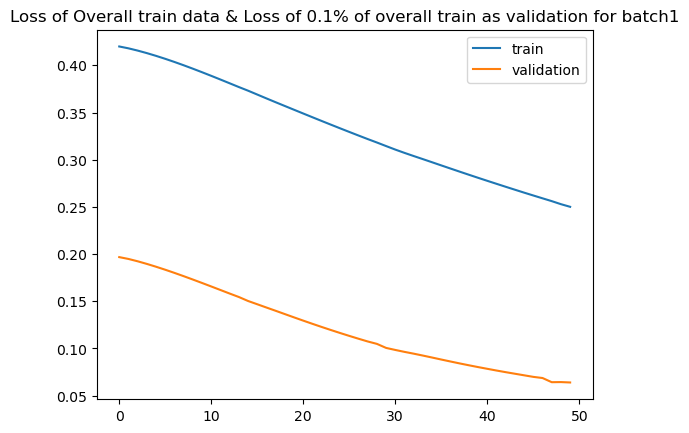

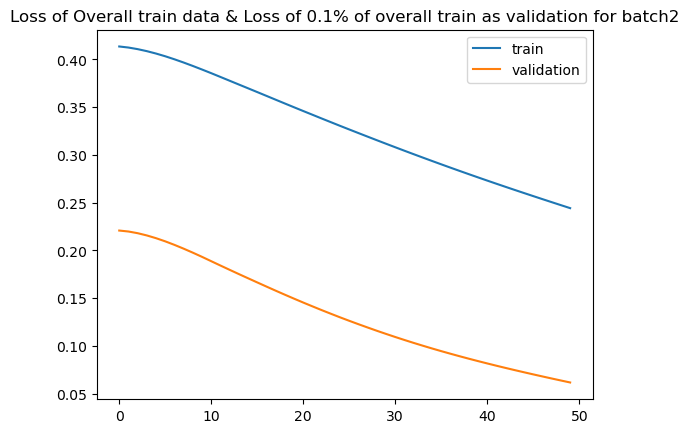

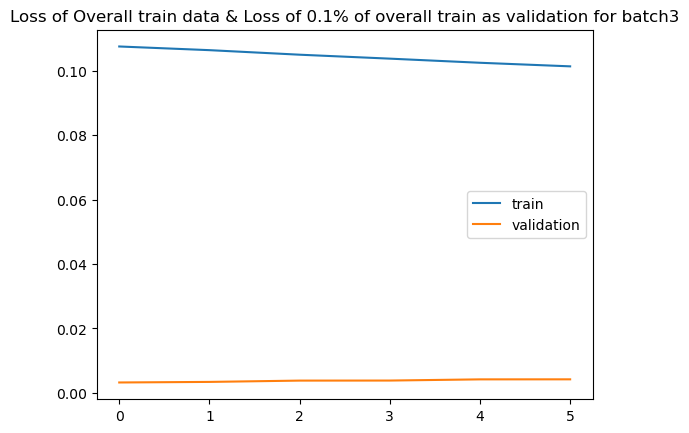

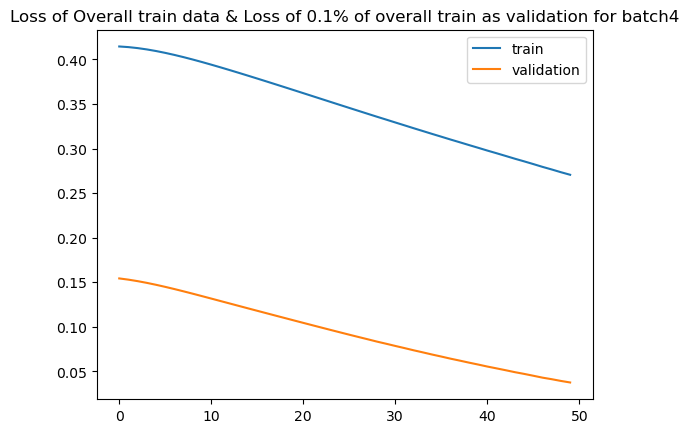

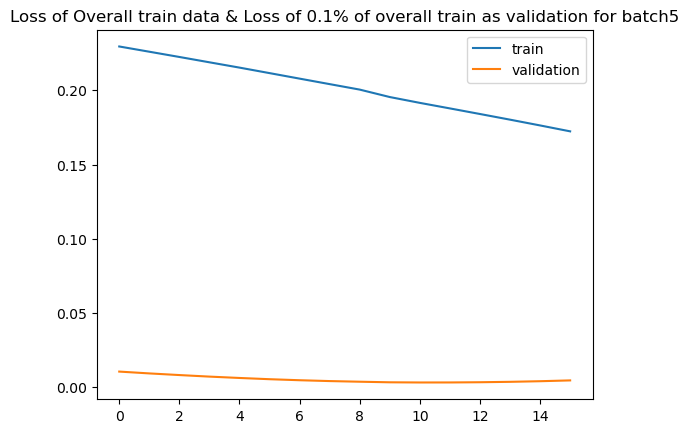

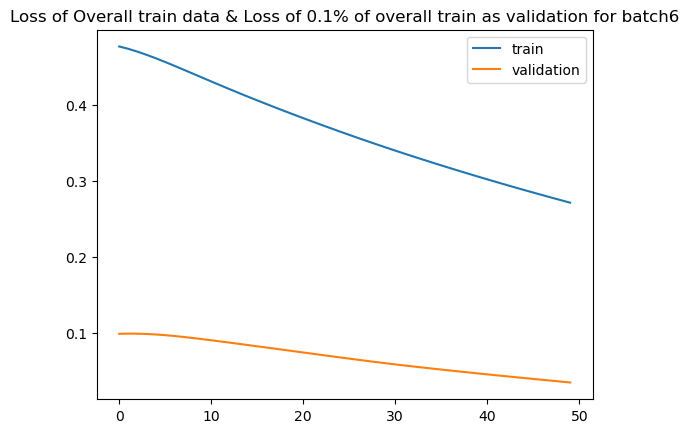

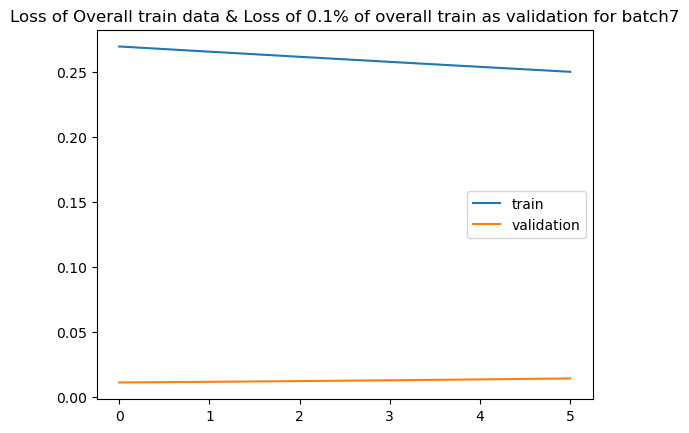

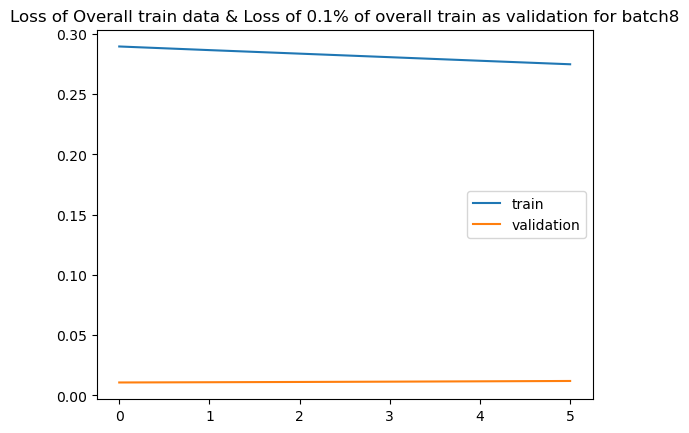

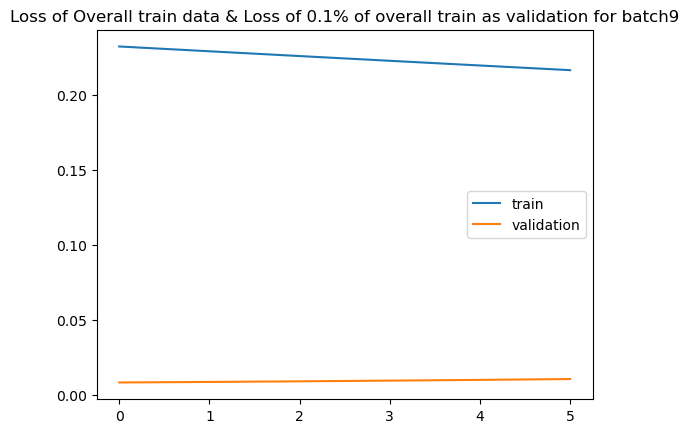

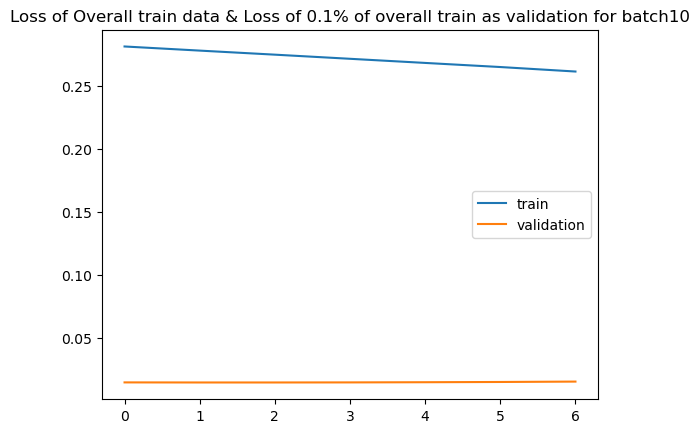

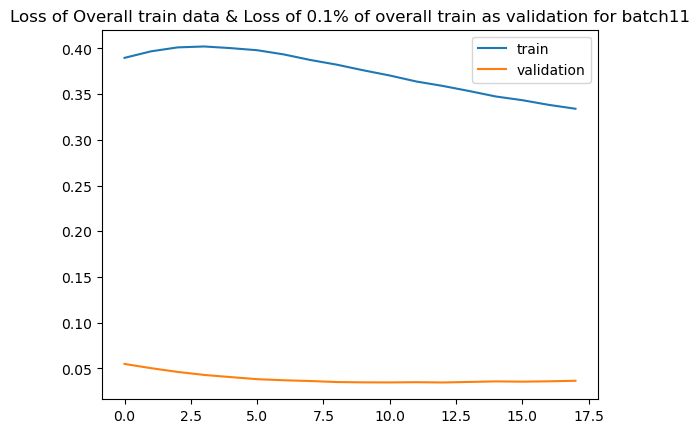

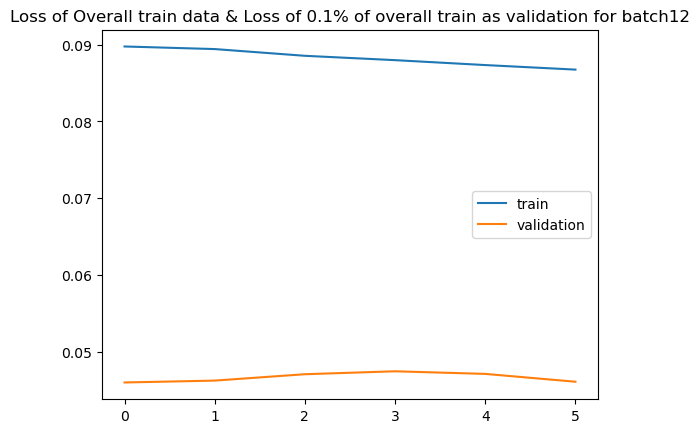

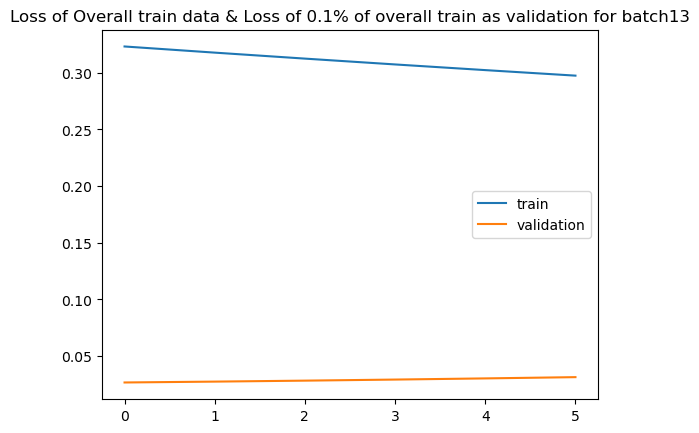

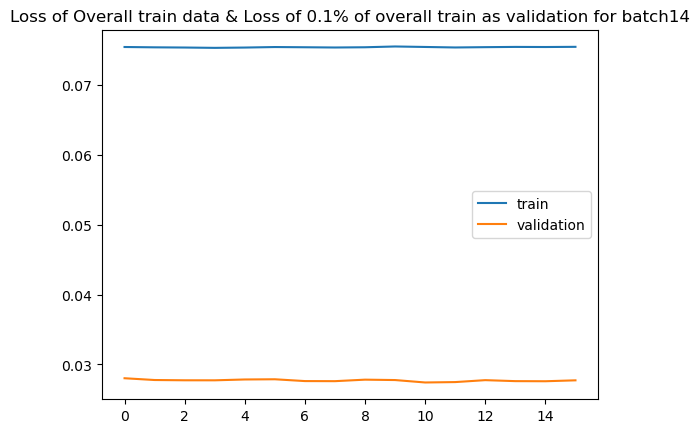

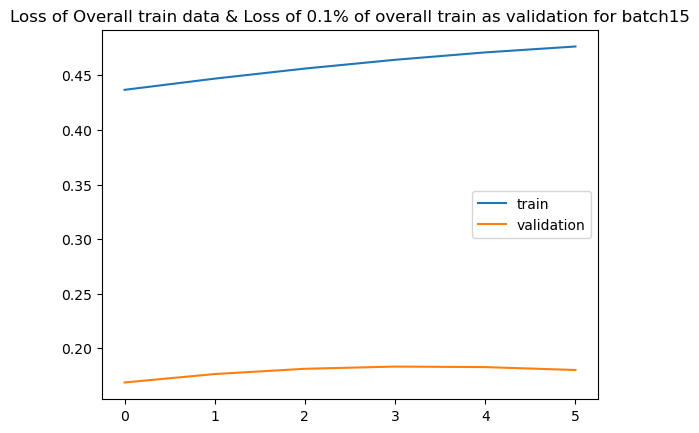

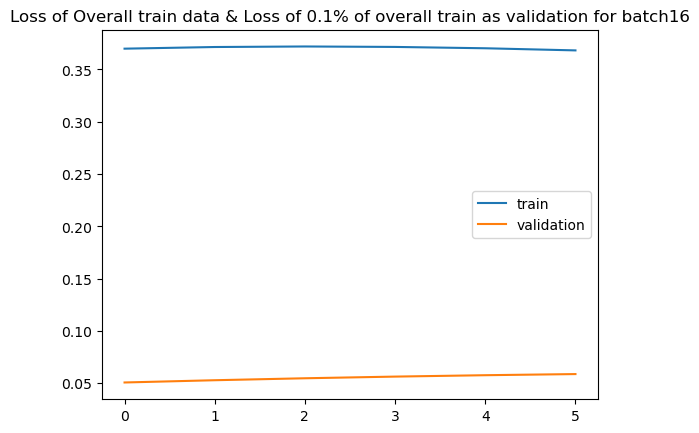

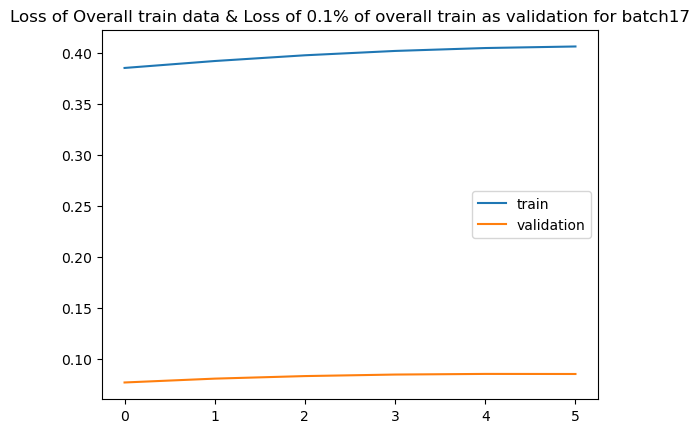

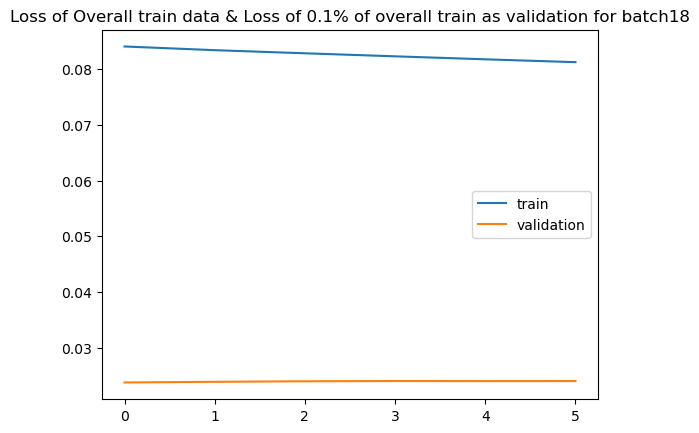

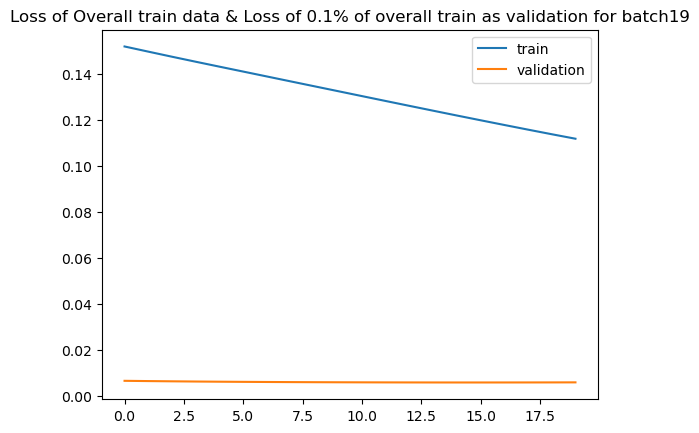

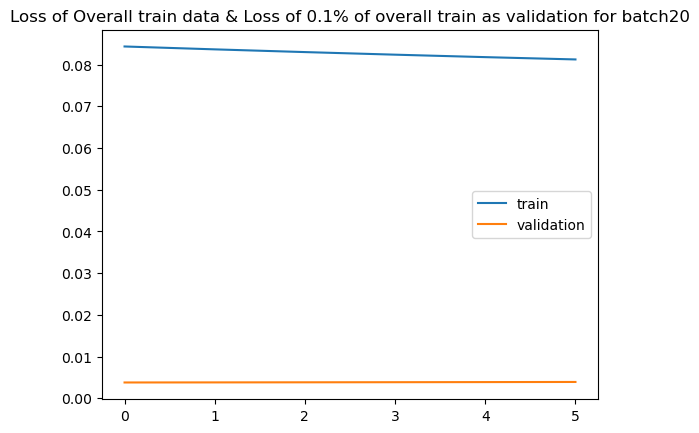

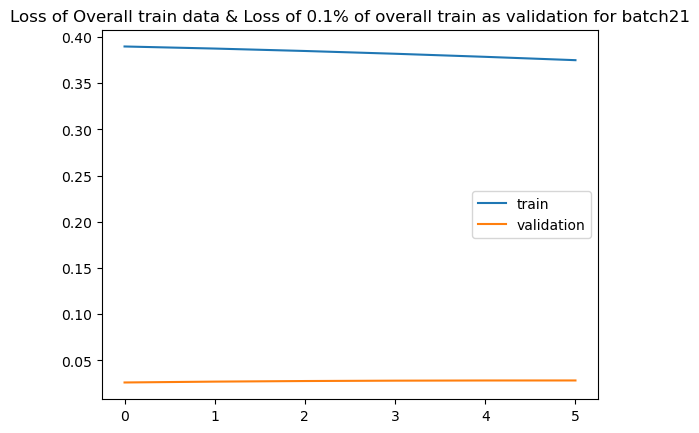

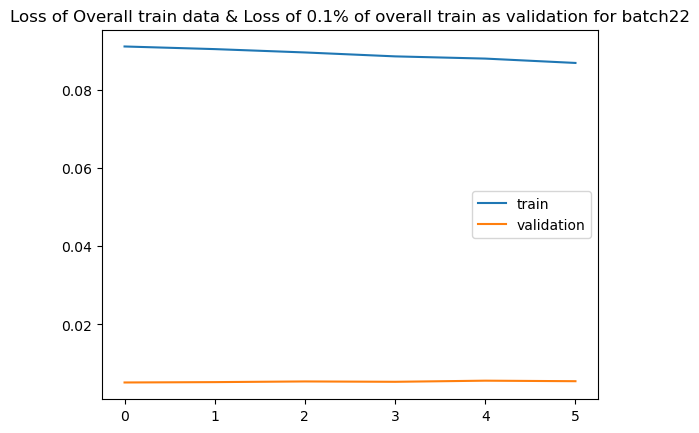

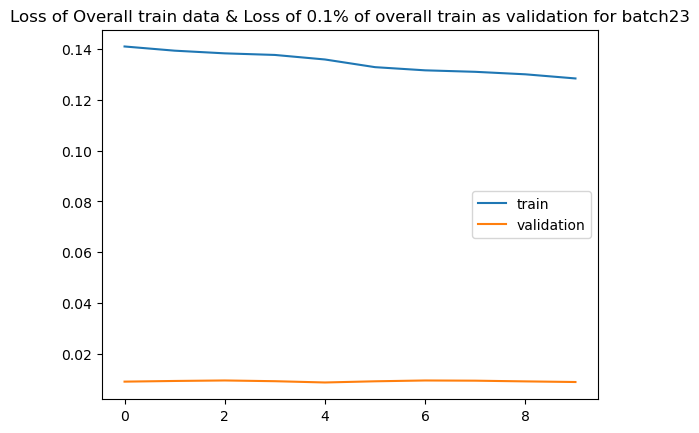

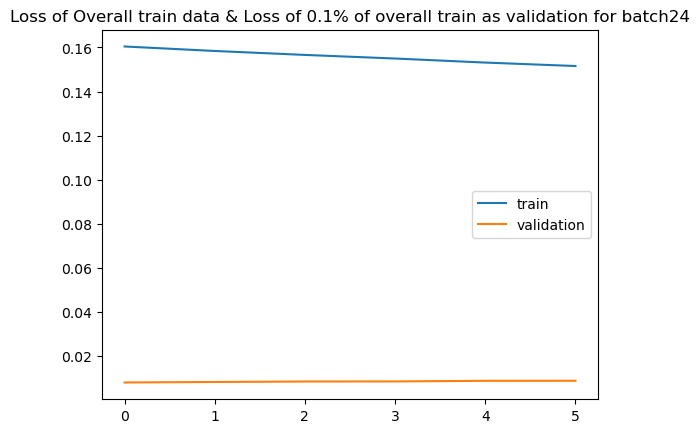

In [46]:
for i in range(1,25):
    plt.title(f"Loss of Overall train data & Loss of 0.1% of overall train as validation for batch{i}")
    plt.plot(history_f[f"{i}"].history['loss'], label='train')
    plt.plot(history_f[f"{i}"].history['val_loss'], label='validation')
    plt.legend()
    plt.show();

### Loading Saved Model

In [49]:
model={}
Model={}

for i in range(1,25):
    model[f"{i}"]= f"D:\ML_Proj\CP forecasting\\lstm_model_fl{i}.h5"
    Model[f"{i}"]= tf.keras.models.load_model(model[f"{i}"])

In [65]:
dX["2"][-1:]

array([[[6.4232],
        [6.4914],
        [6.5255],
        [6.5482],
        [6.5482]]])

In [66]:
Model['2'].predict(dX["2"][-1:])

1/1 [==============================] - 0s 20ms/step


array([[6.772993]], dtype=float32)

In [50]:
pred={}
for i in range(1,25):
    pred[f"{i}"]=Model[f"{i}"].predict(dX[f"{i}"][-1:])
    print(pred[f"{i}"].shape)

1/1 [==============================] - 1s 540ms/step
(1, 1)
1/1 [==============================] - 1s 545ms/step
(1, 1)
1/1 [==============================] - 1s 546ms/step
(1, 1)
1/1 [==============================] - 1s 550ms/step
(1, 1)
1/1 [==============================] - 1s 541ms/step
(1, 1)
1/1 [==============================] - 1s 540ms/step
(1, 1)
1/1 [==============================] - 1s 548ms/step
(1, 1)
1/1 [==============================] - 1s 550ms/step
(1, 1)
1/1 [==============================] - 1s 571ms/step
(1, 1)
1/1 [==============================] - 1s 551ms/step
(1, 1)
1/1 [==============================] - 1s 551ms/step
(1, 1)
1/1 [==============================] - 1s 551ms/step
(1, 1)
1/1 [==============================] - 1s 542ms/step
(1, 1)
1/1 [==============================] - 1s 549ms/step
(1, 1)
1/1 [==============================] - 1s 555ms/step
(1, 1)
1/1 [==============================] - 1s 552ms/step
(1, 1)
1/1 [==============================] - 1

In [67]:
future_steps={}
future_predictions={}
last_sequence={}

num_steps=5
for i in range(1,25):
    # Define the number of future steps to forecast
    future_steps[f"{i}"] = 4  # Adjust this according to your requirement
    # Initialize an empty array to store future predictions
    future_predictions[f"{i}"] = []
    # Use the last few data points from the dataset as input for forecasting
    last_sequence[f"{i}"] = dX[f"{i}"][-num_steps:]

In [72]:
out=Model["2"].predict(last_sequence["2"])

1/1 [==============================] - 0s 19ms/step


In [73]:
out

array([[6.625127 ],
       [6.671929 ],
       [6.719599 ],
       [6.7530828],
       [6.7729936]], dtype=float32)

In [59]:
next_pred={}
for i in range(1,25):
    # Iterate to forecast future values step by step
    for j in range(future_steps[f"{i}"]):
        # Predict the next value
        next_pred[f"{i}"] = Model[f"{i}"].predict(last_sequence[f"{i}"])
        print(next_pred[f"{i}"])
        # Append the predicted value to the list of future predictions
        future_predictions[f"{i}"].append(next_pred[f"{i}"][0, 0])
        
        # Update the input sequence by removing the first value and adding the predicted value at the end
        last_sequence[f"{i}"] = np.roll(last_sequence[f"{i}"], -1, axis=1)
        last_sequence[f"{i}"][0, -1, 0] = next_pred[f"{i}"]

TypeError: in user code:

    File "c:\Users\manirathinams\AppData\Local\anaconda3\Lib\site-packages\keras\src\engine\training.py", line 2440, in predict_function  *
        return step_function(self, iterator)
    File "c:\Users\manirathinams\AppData\Local\anaconda3\Lib\site-packages\keras\src\engine\training.py", line 2425, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Users\manirathinams\AppData\Local\anaconda3\Lib\site-packages\keras\src\engine\training.py", line 2413, in run_step  **
        outputs = model.predict_step(data)
    File "c:\Users\manirathinams\AppData\Local\anaconda3\Lib\site-packages\keras\src\engine\training.py", line 2381, in predict_step
        return self(x, training=False)
    File "c:\Users\manirathinams\AppData\Local\anaconda3\Lib\site-packages\keras\src\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "c:\Users\manirathinams\AppDat

In [20]:
# Load Model
model= "D:\ML_Proj\CP forecasting\model.h5"
Model= tf.keras.models.load_model(model)

### Inferencing

In [21]:
train_pred = Model.predict(train_X)
test_pred = Model.predict(test_X)

3/3 [==============================] - 0s 2ms/step


In [22]:
### Calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error

# RMSE
train_rmse= math.sqrt(mean_squared_error(train_y, train_pred))
train_mae= mean_absolute_error(train_y, train_pred)
#RMSE
test_rmse= math.sqrt(mean_squared_error(test_y, test_pred))
test_mae= mean_absolute_error(test_y, test_pred)
print(f"Train RMSE: {train_rmse}")
print(f"Test RMSE: {test_rmse}")

print(f"Train MAE: {train_mae}")
print(f"Test MAE: {test_mae}")



Train RMSE: 0.4373643460455492
Test RMSE: 0.18998256240007252
Train MAE: 0.2949410569654469
Test MAE: 0.13031404546235742


In [23]:
dfrs= pd.DataFrame(test_pred, columns=['Predictions'])
dfrs['Actuals']= pd.DataFrame(test_y)
dfrs.head(3)

,Predictions,Actuals
0,3.848829,3.6908
1,3.812915,3.6498
2,3.776965,3.6493


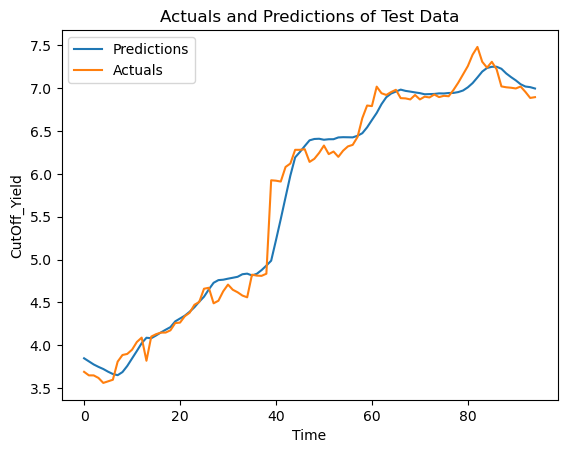

In [24]:
import matplotlib.pyplot as plt
plt.plot()
plt.plot()

# Plotting the training and validation losses

plt.plot(dfrs['Predictions'], label='Predictions')
plt.plot(dfrs['Actuals'], label='Actuals')
plt.xlabel('Time')
plt.ylabel('CutOff_Yield')
plt.title('Actuals and Predictions of Test Data')
plt.legend()
plt.show()

### Training on whole dataset

In [25]:
WINDOW_SIZE= 5

#Convert the dataframe into array
dataf= np.array(df)

# reshape into X=t,t+1,t+2,t+3 and Y=t+4
x, y = data_to_x_y(dataf, window_size= WINDOW_SIZE)

# reshape input into LSTM format - [samples, time steps, features]
X = x.reshape(x.shape[0],x.shape[1], 1)
print(X.shape, y.shape)

(493, 5, 1) (493,)


In [26]:
Model.compile(loss='mean_absolute_error', optimizer= tf.keras.optimizers.Adam(learning_rate=1e-4))

In [27]:
# Model train

earlystop_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("model1.h5", monitor='val_loss', save_best_only=True)

callbacks = [earlystop_cb, checkpoint_cb]

History = Model.fit(X, y, epochs=100, batch_size=16, validation_split=0.10, callbacks=callbacks) #validation_split=0.10

Epoch 1/100
28/28 [==============================] - 5s 40ms/step - loss: 0.2656 - val_loss: 0.1321
Epoch 2/100
20/28 [====================>.........] - ETA: 0s - loss: 0.2498

c:\Users\manirathinams\AppData\Local\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


28/28 [==============================] - 0s 9ms/step - loss: 0.2387 - val_loss: 0.1048
Epoch 3/100
28/28 [==============================] - 0s 6ms/step - loss: 0.2263 - val_loss: 0.1355
Epoch 4/100
28/28 [==============================] - 0s 7ms/step - loss: 0.2175 - val_loss: 0.1082
Epoch 5/100
28/28 [==============================] - 0s 7ms/step - loss: 0.2133 - val_loss: 0.1477
Epoch 6/100
28/28 [==============================] - 0s 6ms/step - loss: 0.2050 - val_loss: 0.1249
Epoch 7/100
28/28 [==============================] - 0s 7ms/step - loss: 0.1977 - val_loss: 0.1732


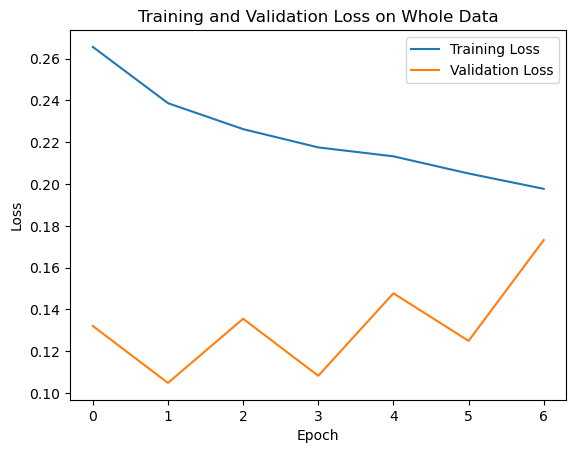

In [28]:
# Accessing the training history

train_loss = History.history['loss']
val_loss = History.history['val_loss']

# Plotting the training and validation losses

plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss on Whole Data')
plt.legend()
plt.show()

### Inferencing on future data

In [29]:
d= data.iloc[-5:,:]
d.head(5)

,CutOff_Yield
Date,
2023-05-03,6.9955
2023-05-10,7.0182
2023-05-17,6.9554
2023-05-24,6.8850
2023-05-31,6.8941


In [30]:
# Converting the inputs shape as per model forecast 

inp= np.array(d['CutOff_Yield'])
inp= inp.reshape(1,5,1)
inp

array([[[6.9955],
        [7.0182],
        [6.9554],
        [6.885 ],
        [6.8941]]])

In [31]:
# Load Model
model= "D:\ML_Proj\CP forecasting\model1.h5"
lstm_model= tf.keras.models.load_model(model)

In [32]:
# user defined function to forecast future values

def forecast_future_value(inp):
    out = lstm_model.predict(inp)
    inp = np.append(inp, out.reshape(1,1,1), axis=1)
    inp = np.delete(inp, 0, axis=1)
    return inp, out


In [33]:
forecast=[]
inputs=[]
for i in range(4):
    inp, out=forecast_future_value(inp)
    forecast.append(out[0][0])
    inputs.append(inp[0])
    print("Predicted value:", out[0][0])

1/1 [==============================] - 1s 886ms/step
Predicted value: 6.9686446
1/1 [==============================] - 0s 29ms/step
Predicted value: 6.9604425
1/1 [==============================] - 0s 27ms/step
Predicted value: 6.955225
1/1 [==============================] - 0s 29ms/step
Predicted value: 6.9597483


In [34]:
index= ['1st','2nd','3rd','4th']

# taking actual data and forming dataframe
actual= dfs['CutOff_Yield']
actual.index= index
act = pd.DataFrame(actual)
act.rename(columns={"CutOff_Yield":"Actuals"}, inplace=True)

# taking the forecast value and forming dataframe
preds = pd.DataFrame(forecast, columns=['Forecasted'], index=index)

#concat the two dataframes into one
output= pd.concat([act, preds], axis=1)
output

,Actuals,Forecasted
1st,6.8570,6.968645
2nd,6.9051,6.960443
3rd,6.8901,6.955225
4th,6.8685,6.959748


### 3 Months Forecast

In [35]:
rmse= math.sqrt(mean_squared_error(output['Actuals'], output['Forecasted']))

mae= mean_absolute_error(output['Actuals'], output['Forecasted'])

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

RMSE: 0.08380756064754935
MAE: 0.0808401052474974


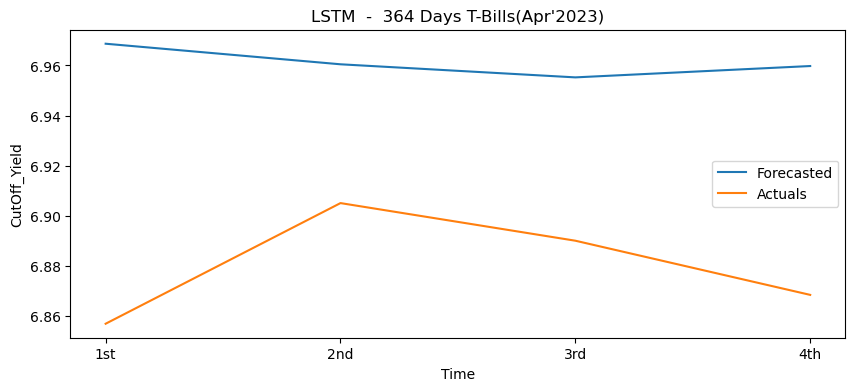

In [36]:
import matplotlib.pyplot as plt
#plt.plot()

# Plotting the training and validation losses
plt.figure(figsize=(10,4))
plt.plot(output['Forecasted'], label='Forecasted')
plt.plot(output['Actuals'], label='Actuals')
plt.xlabel('Time')
plt.ylabel('CutOff_Yield')
plt.title("LSTM  -  364 Days T-Bills(Apr'2023)")
plt.legend()
plt.show()